# all

## Import & Konfigurasi Global

In [24]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

matplotlib.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       600,
    "font.family":       "serif",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
})

# Warna cerah Server 1 / Server 2
C_S1 = "#0096FF"   # biru cerah
C_S2 = "#FF6F00"   # oranye cerah

# ── SESUAIKAN PATH INI ──────────────────────────────────────
BASE_DIR = Path("~/code/loadBalancer/project-fpso/logs").expanduser()
 
SCENARIOS = {
    "ramp_run1": {
        "base":      BASE_DIR / "ramp/run1/test_base_ramp.csv",
        "optimized": BASE_DIR / "ramp/run1/test_opt_ramp.csv",
        "out_dir":   BASE_DIR / "ramp/run1/figures",
    },
    "ramp_run2": {
        "base":      BASE_DIR / "ramp/run2/test_base_ramp.csv",
        "optimized": BASE_DIR / "ramp/run2/test_opt_ramp.csv",
        "out_dir":   BASE_DIR / "ramp/run2/figures",
    },
    "ramp_run3": {
        "base":      BASE_DIR / "ramp/run3/test_base_ramp.csv",
        "optimized": BASE_DIR / "ramp/run3/test_opt_ramp.csv",
        "out_dir":   BASE_DIR / "ramp/run3/figures",
    },
}

REQUIRED_COLS = [
    "timestamp_utc",
    "node1_cpu_normalized_usage",
    "node2_cpu_normalized_usage",
    "node1_response_ms",
    "node2_response_ms",
    "node1_requests",
    "node2_requests",
    "node1_queue",
    "node2_queue",
]

MOVING_AVG_WINDOW = 5

## Fungsi Bantu (load, hitung metrik)

In [25]:
def load_csv(path: Path, label: str) -> pd.DataFrame:
    df = pd.read_csv(path, skipinitialspace=True)
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], errors="coerce", utc=True)
    for c in REQUIRED_COLS:
        if c != "timestamp_utc":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["timestamp_utc"]).sort_values("timestamp_utc").reset_index(drop=True)
    df["total_requests"] = df["node1_requests"].fillna(0) + df["node2_requests"].fillna(0)
    df = df[df["total_requests"] > 0].reset_index(drop=True)
    df["t"] = (df["timestamp_utc"] - df["timestamp_utc"].iloc[0]).dt.total_seconds()

    # filter outlier CPU — titik ekstrem saat node aktif diganti interpolasi
    for col in ["node1_cpu_normalized_usage", "node2_cpu_normalized_usage"]:
        node_col = "node1_requests" if "node1" in col else "node2_requests"
        active = df[node_col] > 0
        q_low  = df.loc[active, col].quantile(0.03)
        q_high = df.loc[active, col].quantile(0.98)
        df.loc[active & ((df[col] < q_low) | (df[col] > q_high)), col] = np.nan
        df[col] = df[col].interpolate(method="linear")

    # moving average
    df["cpu1_ma"] = df["node1_cpu_normalized_usage"].rolling(MOVING_AVG_WINDOW, min_periods=1).mean()
    df["cpu2_ma"] = df["node2_cpu_normalized_usage"].rolling(MOVING_AVG_WINDOW, min_periods=1).mean()
    df["rt1_ma"]  = df["node1_response_ms"].rolling(MOVING_AVG_WINDOW, min_periods=1).mean()
    df["rt2_ma"]  = df["node2_response_ms"].rolling(MOVING_AVG_WINDOW, min_periods=1).mean()
    df["label"] = label
    return df


def compute_metrics(base_df: pd.DataFrame, opt_df: pd.DataFrame) -> dict:
    def _di(df):
        return float(np.mean(np.abs(
            df["node1_cpu_normalized_usage"].to_numpy(float) -
            df["node2_cpu_normalized_usage"].to_numpy(float)
        ) / 100.0))

    def _art(df):
        rt1   = df["node1_response_ms"].fillna(0).to_numpy(float)
        rt2   = df["node2_response_ms"].fillna(0).to_numpy(float)
        r1    = df["node1_requests"].fillna(0).to_numpy(float)
        r2    = df["node2_requests"].fillna(0).to_numpy(float)
        total = r1 + r2
        mask  = total > 0
        art_row = np.where(mask, (rt1*r1 + rt2*r2) / np.where(mask, total, 1), 0)
        return float(np.mean(art_row[mask]))

    def _cpu_mean(df, node):
        return float(df[f"node{node}_cpu_normalized_usage"].mean())

    def _rt_mean(df, node):
        return float(df[f"node{node}_response_ms"].mean())

    return {
        "DI Base":          _di(base_df),
        "DI Opt":           _di(opt_df),
        "ART Base (ms)":    _art(base_df),
        "ART Opt (ms)":     _art(opt_df),
        "CPU1 Base (%)":    _cpu_mean(base_df, 1),
        "CPU1 Opt (%)":     _cpu_mean(opt_df,  1),
        "CPU2 Base (%)":    _cpu_mean(base_df, 2),
        "CPU2 Opt (%)":     _cpu_mean(opt_df,  2),
        "RT1 Base (ms)":    _rt_mean(base_df, 1),
        "RT1 Opt (ms)":     _rt_mean(opt_df,  1),
        "RT2 Base (ms)":    _rt_mean(base_df, 2),
        "RT2 Opt (ms)":     _rt_mean(opt_df,  2),
    }

## Visualisasi DI (CPU Utilization) per Skenario

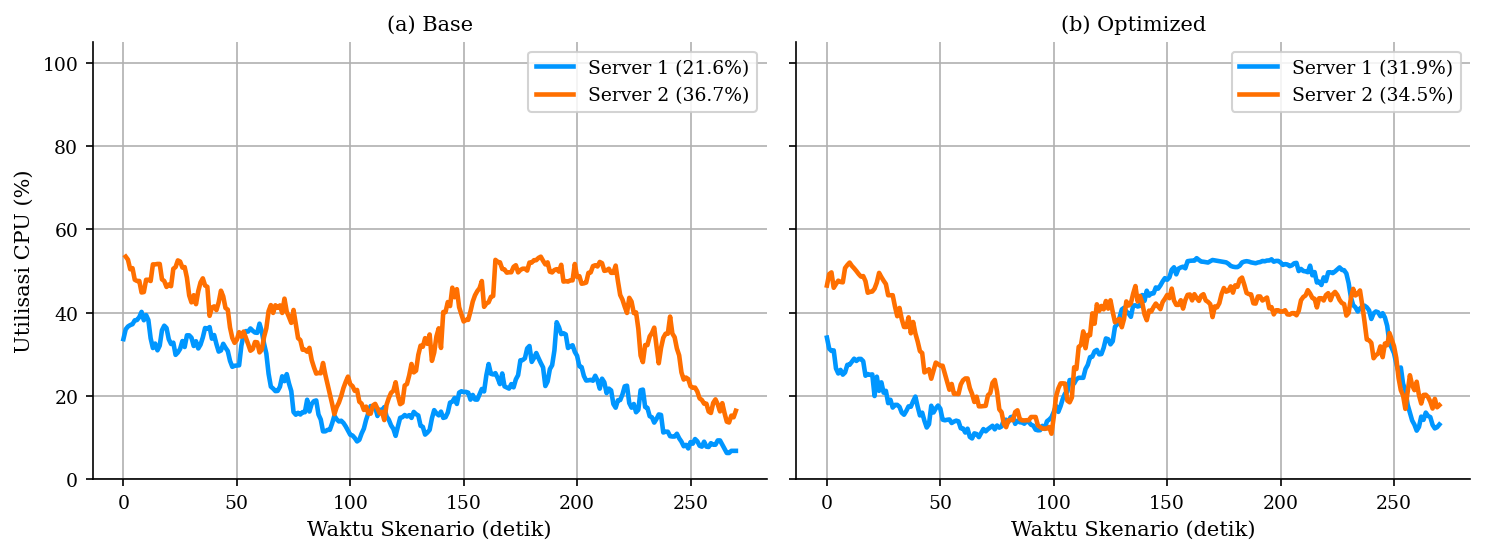

Tersimpan: /home/asus/code/loadBalancer/project-fpso/logs/ramp/run1/figures/di_ramp_run1.png

Table. DI — Skenario ramp_run1
      Metrik  Nilai
     DI Base    nan
DI Optimized 0.1063
     ΔDI (↑)    nan



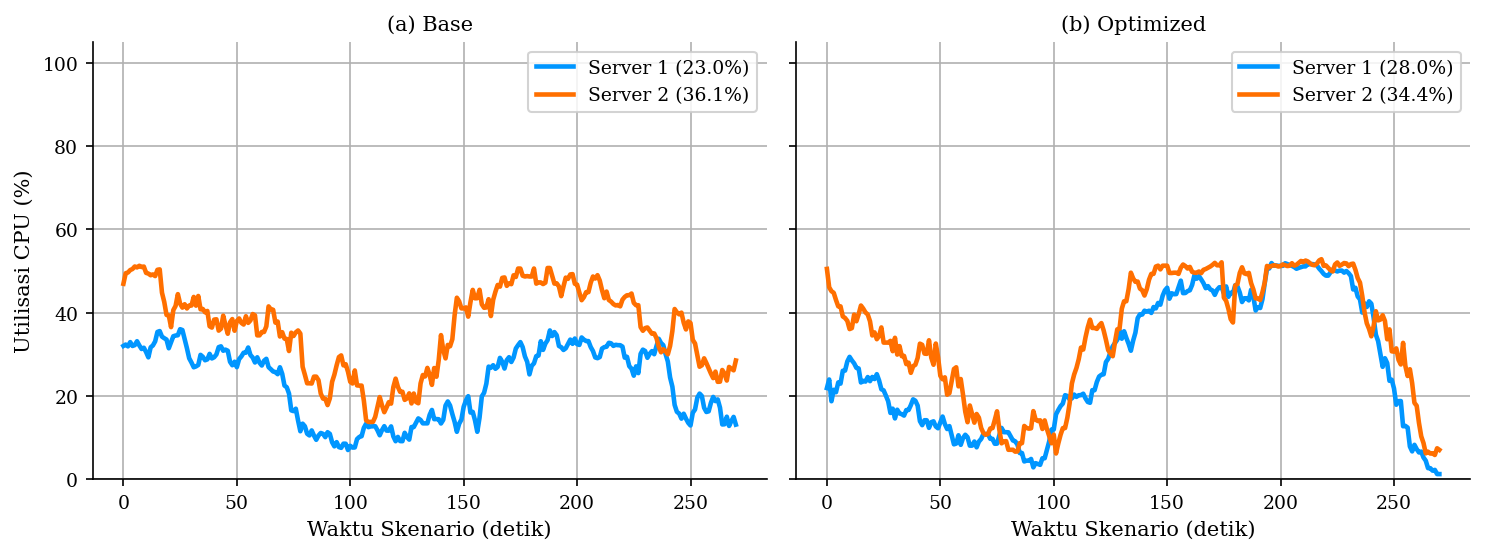

Tersimpan: /home/asus/code/loadBalancer/project-fpso/logs/ramp/run2/figures/di_ramp_run2.png

Table. DI — Skenario ramp_run2
      Metrik  Nilai
     DI Base 0.1484
DI Optimized 0.1011
     ΔDI (↓) 0.0473



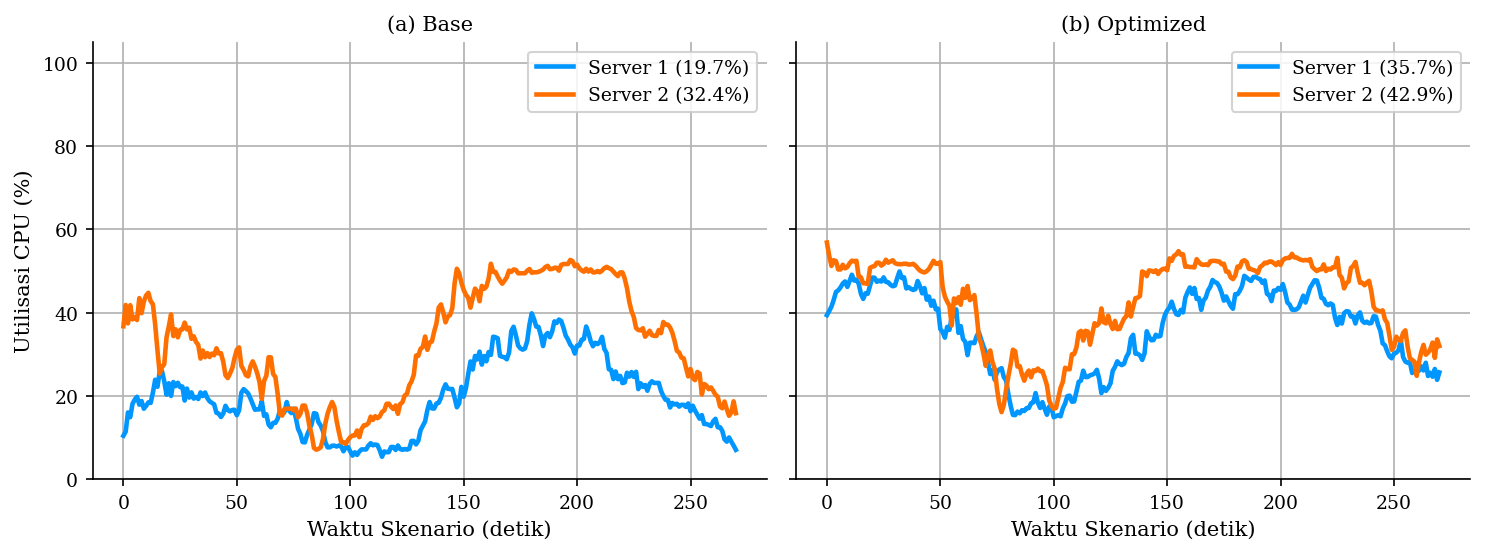

Tersimpan: /home/asus/code/loadBalancer/project-fpso/logs/ramp/run3/figures/di_ramp_run3.png

Table. DI — Skenario ramp_run3
      Metrik  Nilai
     DI Base 0.1469
DI Optimized 0.0973
     ΔDI (↓) 0.0496



In [26]:
def plot_di(scenario_name: str, base_df: pd.DataFrame, opt_df: pd.DataFrame,
            out_dir: Path, metrics: dict):
    out_dir.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)

    panel_data = [
        ("(a) Base",      base_df, metrics["CPU1 Base (%)"], metrics["CPU2 Base (%)"]),
        ("(b) Optimized", opt_df,  metrics["CPU1 Opt (%)"],  metrics["CPU2 Opt (%)"]),
    ]

    for ax, (subtitle, df, avg1, avg2) in zip(axes, panel_data):
        t = df["t"].to_numpy(float)
        ax.plot(t, df["cpu1_ma"], color=C_S1, linewidth=2.2,
                label=f"Server 1 ({avg1:.1f}%)")
        ax.plot(t, df["cpu2_ma"], color=C_S2, linewidth=2.2,
                label=f"Server 2 ({avg2:.1f}%)")
        ax.set_title(subtitle, fontsize=10)
        ax.set_xlabel("Waktu Skenario (detik)")
        ax.set_ylim(0, 105)
        ax.legend(loc="upper right", framealpha=0.85)

    axes[0].set_ylabel("Utilisasi CPU (%)")
    fig.tight_layout()

    out_path = out_dir / f"di_{scenario_name.lower()}.png"
    fig.savefig(out_path, dpi=600, bbox_inches="tight")
    plt.show()
    print(f"Tersimpan: {out_path.resolve()}")
    plt.close(fig)

    di_base = metrics["DI Base"]
    di_opt  = metrics["DI Opt"]
    delta   = di_opt - di_base
    sign    = "↓" if delta < 0 else "↑"
    tbl = pd.DataFrame([
        ["DI Base",      f"{di_base:.4f}"],
        ["DI Optimized", f"{di_opt:.4f}"],
        [f"ΔDI ({sign})", f"{abs(delta):.4f}"],
    ], columns=["Metrik", "Nilai"])
    print(f"\nTable. DI — Skenario {scenario_name}")
    print(tbl.to_string(index=False))
    print()


all_metrics = {}
for name, cfg in SCENARIOS.items():
    base_df = load_csv(cfg["base"], "Base")
    opt_df  = load_csv(cfg["optimized"], "Optimized")
    m = compute_metrics(base_df, opt_df)
    all_metrics[name] = m
    plot_di(name, base_df, opt_df, cfg["out_dir"], m)

## Visualisasi ART (Response Time) per Skenario

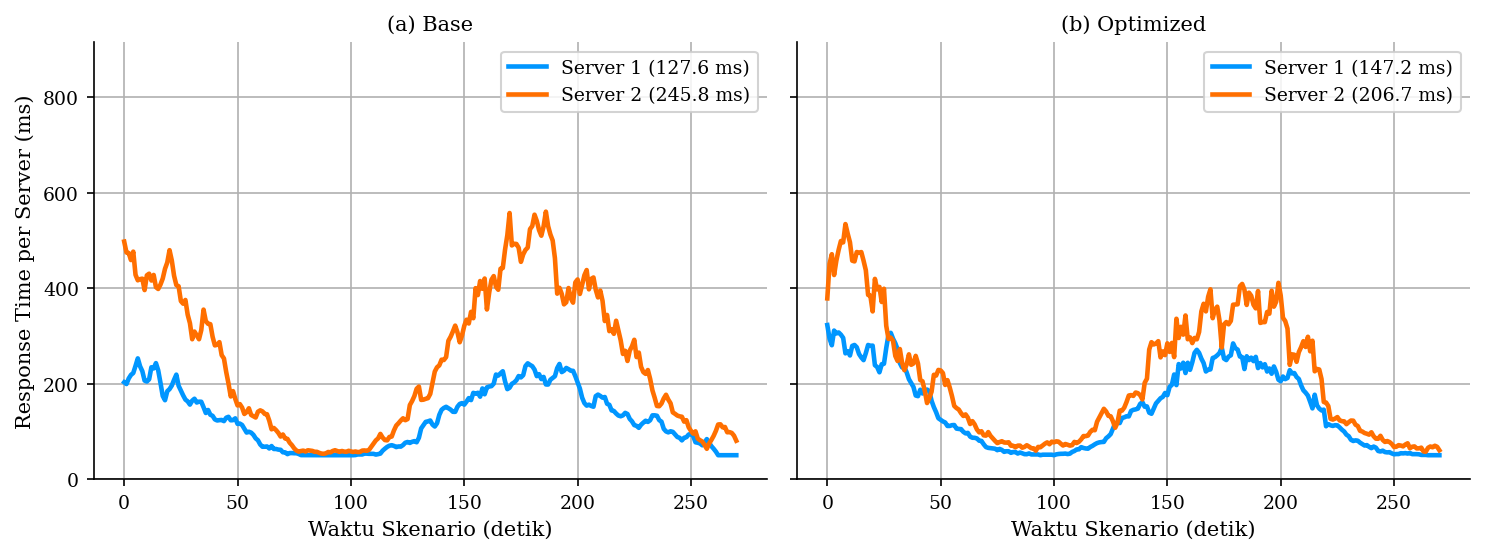

Tersimpan: /home/asus/code/loadBalancer/project-fpso/logs/ramp/run1/figures/art_ramp_run1.png

Table. ART — Skenario ramp_run1
            Metrik  Nilai
     ART Base (ms) 188.02
ART Optimized (ms) 175.76
          ΔART (↓)  12.26



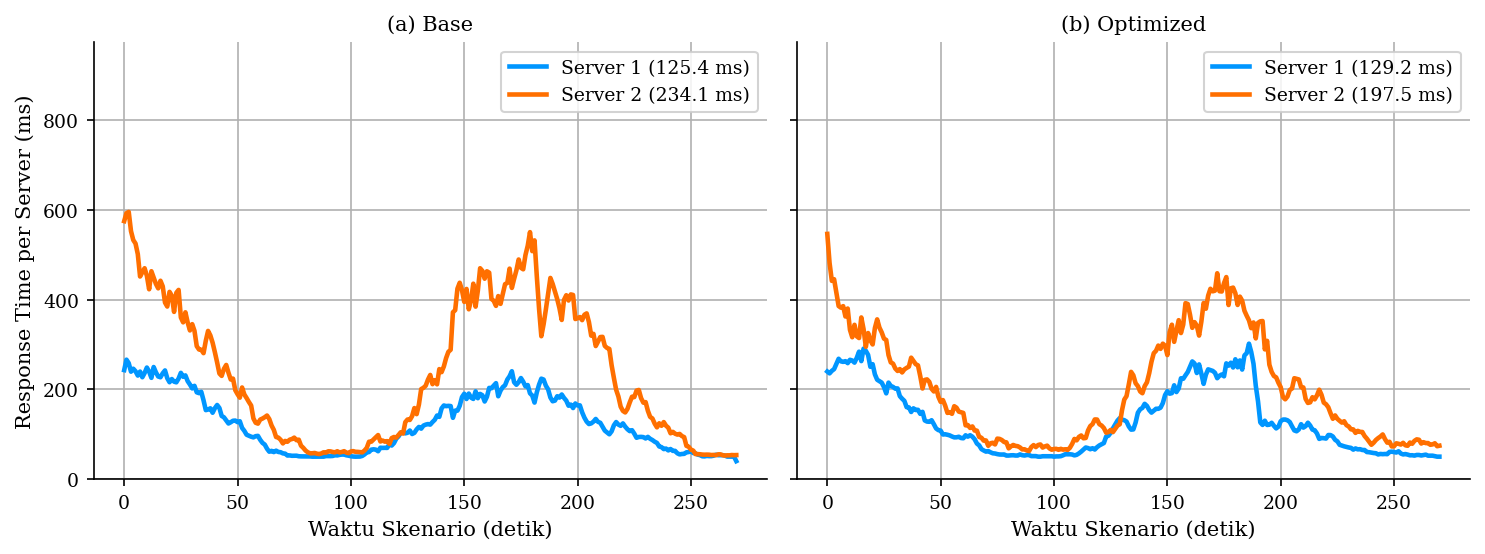

Tersimpan: /home/asus/code/loadBalancer/project-fpso/logs/ramp/run2/figures/art_ramp_run2.png

Table. ART — Skenario ramp_run2
            Metrik  Nilai
     ART Base (ms) 180.76
ART Optimized (ms) 161.60
          ΔART (↓)  19.16



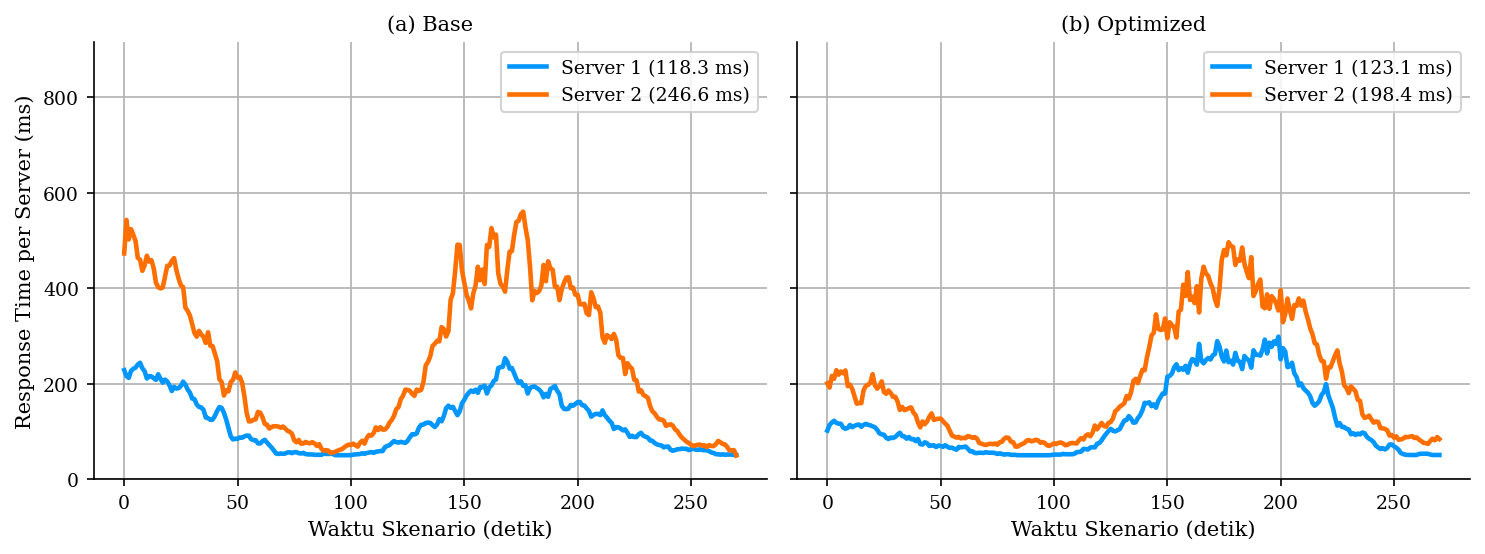

Tersimpan: /home/asus/code/loadBalancer/project-fpso/logs/ramp/run3/figures/art_ramp_run3.png

Table. ART — Skenario ramp_run3
            Metrik  Nilai
     ART Base (ms) 181.16
ART Optimized (ms) 161.69
          ΔART (↓)  19.47



In [27]:
def plot_art(scenario_name: str, base_df: pd.DataFrame, opt_df: pd.DataFrame,
             out_dir: Path, metrics: dict):
    out_dir.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)

    panel_data = [
        ("(a) Base",      base_df, metrics["RT1 Base (ms)"], metrics["RT2 Base (ms)"]),
        ("(b) Optimized", opt_df,  metrics["RT1 Opt (ms)"],  metrics["RT2 Opt (ms)"]),
    ]

    for ax, (subtitle, df, avg1, avg2) in zip(axes, panel_data):
        t = df["t"].to_numpy(float)
        ax.plot(t, df["rt1_ma"], color=C_S1, linewidth=2.2,
                label=f"Server 1 ({avg1:.1f} ms)")
        ax.plot(t, df["rt2_ma"], color=C_S2, linewidth=2.2,
                label=f"Server 2 ({avg2:.1f} ms)")
        ax.set_title(subtitle, fontsize=10)
        ax.set_ylim(bottom=0, top=ax.get_ylim()[1] * 1.25)
        ax.set_xlabel("Waktu Skenario (detik)")
        ax.legend(loc="upper right", framealpha=0.85)

    axes[0].set_ylabel("Response Time per Server (ms)")
    fig.tight_layout()

    out_path = out_dir / f"art_{scenario_name.lower()}.png"
    fig.savefig(out_path, dpi=600, bbox_inches="tight")
    plt.show()
    print(f"Tersimpan: {out_path.resolve()}")
    plt.close(fig)

    art_base = metrics["ART Base (ms)"]
    art_opt  = metrics["ART Opt (ms)"]
    delta    = art_opt - art_base
    sign     = "↓" if delta < 0 else "↑"
    tbl = pd.DataFrame([
        ["ART Base (ms)",      f"{art_base:.2f}"],
        ["ART Optimized (ms)", f"{art_opt:.2f}"],
        [f"ΔART ({sign})",     f"{abs(delta):.2f}"],
    ], columns=["Metrik", "Nilai"])
    print(f"\nTable. ART — Skenario {scenario_name}")
    print(tbl.to_string(index=False))
    print()


for name, cfg in SCENARIOS.items():
    base_df = load_csv(cfg["base"], "Base")
    opt_df  = load_csv(cfg["optimized"], "Optimized")
    plot_art(name, base_df, opt_df, cfg["out_dir"], all_metrics[name])

## Tabel Ringkasan Semua Skenario

In [ ]:
rows = []
for name, m in all_metrics.items():
    delta_di  = m["DI Opt"]       - m["DI Base"]
    delta_art = m["ART Opt (ms)"] - m["ART Base (ms)"]
    rows.append({
        "Skenario":        name,
        "DI Base":         round(m["DI Base"],        4),
        "DI Optimized":    round(m["DI Opt"],          4),
        "ΔDI":             round(delta_di,             4),
        "ART Base (ms)":   round(m["ART Base (ms)"],   2),
        "ART Opt (ms)":    round(m["ART Opt (ms)"],    2),
        "ΔART (ms)":       round(delta_art,            2),
    })

summary_df = pd.DataFrame(rows)
print("\nTable. Ringkasan Perbandingan Base vs Optimized — Semua Skenario\n")
print(summary_df.to_string(index=False))


Table. Ringkasan Perbandingan Base vs Optimized — Semua Skenario

 Skenario  DI Base  DI Optimized     ΔDI  ART Base (ms)  ART Opt (ms)  ΔART (ms) Status DI Status ART
ramp_run1      NaN        0.1063     NaN         188.02        175.76     -12.26        ⚠️          ✅
ramp_run2   0.1484        0.1011 -0.0473         180.76        161.60     -19.16         ✅          ✅
ramp_run3   0.1469        0.0973 -0.0496         181.16        161.69     -19.47         ✅          ✅


In [29]:
# ganti path ke run 2
df2 = pd.read_csv(BASE_DIR / "spike/run2/test_base_spike.csv")
print(df2[["timestamp_utc",
           "node1_requests", "node2_requests",
           "node1_queue", "node2_queue",
           "node1_cpu_normalized_usage",
           "node2_cpu_normalized_usage"]].iloc[70:100].to_string())

                     timestamp_utc  node1_requests  node2_requests  node1_queue  node2_queue  node1_cpu_normalized_usage  node2_cpu_normalized_usage
70  2026-06-24T03:39:01.841172547Z              76              36         16.0        105.0                   53.000000                   52.000000
71  2026-06-24T03:39:02.841174887Z              69              52          4.0        107.0                   46.846847                   52.000000
72  2026-06-24T03:39:03.841172907Z              35              38          0.0        145.0                   54.022989                   52.000000
73  2026-06-24T03:39:04.841173011Z              63              31         31.0         47.0                   43.636364                   50.000000
74  2026-06-24T03:39:05.841172911Z             105              67         62.0         90.0                   50.931677                   54.901961
75   2026-06-24T03:39:06.84117261Z              64              71         43.0        115.0              